In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite

In [5]:
# ── Config ─────────────────────────────────────────────────────────────────────
DATA_PATH   = "/Users/mahalingaprabhu/Downloads/7817_1.csv"
MIN_RATING   = 4      # only "liked" edges (rating >= 4)
MIN_REVIEWS  = 2      # user must have reviewed at least N products

In [3]:
# ── 1. Load & Clean ────────────────────────────────────────────────────────────

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, on_bad_lines="skip")

    df.rename(columns={
        "reviews.rating":   "rating",
        "reviews.username": "username",
        "reviews.text":     "review_text",
    }, inplace=True)

    df = df[["id", "name", "brand", "categories", "rating", "username", "review_text"]].copy()
    df.dropna(subset=["name", "username", "rating"], inplace=True)

    df["rating"]   = pd.to_numeric(df["rating"], errors="coerce")
    df["username"] = df["username"].str.strip().str.lower()
    df["name"]     = df["name"].str.strip()
    df["brand"]    = df["brand"].fillna("Unknown").str.strip()
    df.dropna(subset=["rating"], inplace=True)

    # Keep users with at least MIN_REVIEWS reviews — sparse users are noise
    user_counts = df["username"].value_counts()
    active_users = user_counts[user_counts >= MIN_REVIEWS].index
    df = df[df["username"].isin(active_users)]

    print(f"[load] {len(df)} interactions | "
          f"{df['username'].nunique()} users | "
          f"{df['name'].nunique()} products")
    return df


In [6]:
print("=== Step 1: Load Data ===")
df = load_data(DATA_PATH)
# products = df["name"].unique() #Product name
# products
df

=== Step 1: Load Data ===
[load] 437 interactions | 91 users | 58 products


,id,name,brand,categories,rating,username,review_text
49,AVpfBEWcilAPnD_xTGb7,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",4.0,matthew coenen,"I'm a first-time Kindle owner, so I have nothi..."
50,AVpfBEWcilAPnD_xTGb7,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",5.0,ron cronovich,UPDATE NOVEMBER 2011:My review is now over a y...
51,AVpfBEWcilAPnD_xTGb7,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",3.0,jeffrey stanley,The Kindle is my first e-ink reader. I own an ...
52,AVpfBEWcilAPnD_xTGb7,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",3.0,jeffrey stanley,The Kindle is my first e-ink reader. I own an ...
53,AVpfBEWcilAPnD_xTGb7,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",4.0,matthew coenen,"I'm a first-time Kindle owner, so I have nothi..."
...,...,...,...,...,...,...,...
1560,AVpge-anilAPnD_xtDVf,Amazon Premium Headphones,Amazon,"Amazon Devices,Corded Headsets,Electronics Fea...",5.0,andrew,"I bought these for a couple of reasons.First, ..."
1583,AVpfODXeilAPnD_xXeUd,Replacement Remote for Amazon Fire TV Stick,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",1.0,amazon customer,"Remote didn't work, did all the troubleshootin..."
1587,AVpfo9ukilAPnD_xfhuj,Alexa Voice Remote for Amazon Fire TV and Fire...,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",2.0,amazon customer,I am now having to order my third remote becau...
1593,AVpfo9ukilAPnD_xfhuj,Alexa Voice Remote for Amazon Fire TV and Fire...,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",1.0,amazon customer,I have had to change the batteries in this rem...


In [7]:
# ── 2. Build Bipartite Graph ───────────────────────────────────────────────────

def build_bipartite_graph(df: pd.DataFrame) -> nx.Graph:
    """
    Bipartite graph: User nodes (bipartite=0) <-> Product nodes (bipartite=1)
    Edge weight = rating (1-5)
    Only edges where rating >= MIN_RATING ("liked")
    """
    B = nx.Graph()

    # Add user nodes
    users = df["username"].unique()
    B.add_nodes_from(users, bipartite=0, node_type="user")

    # Add product nodes — use product name as ID (deduplicated)
    products = df["name"].unique() #Product name
    B.add_nodes_from(products, bipartite=1, node_type="product")

    # Add edges for liked interactions only
    liked = df[df["rating"] >= MIN_RATING]
    for _, row in liked.iterrows():
        user    = row["username"]
        product = row["name"]
        rating  = row["rating"]

        if B.has_edge(user, product):
            # If same user reviewed same product twice, take max rating
            B[user][product]["weight"] = max(B[user][product]["weight"], rating)
        else:
            B.add_edge(user, product,
                weight   = rating,
                edge_type = "LIKED"
            )

    # Attach product metadata to product nodes
    product_meta = (
        df.groupby("name")
          .agg(
              brand      = ("brand", "first"),
              category   = ("categories", "first"),
              avg_rating = ("rating", "mean"),
              num_reviews= ("rating", "count"),
              sample_review = ("review_text", "first"),
          )
          .reset_index()
    )
    for _, row in product_meta.iterrows():
        if row["name"] in B:
            B.nodes[row["name"]].update({
                "brand":       row["brand"],
                "category":    row["category"],
                "avg_rating":  round(row["avg_rating"], 2),
                "num_reviews": row["num_reviews"],
                "sample_review": str(row["sample_review"])[:300],
            })

    user_nodes    = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 0]
    product_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 1]

    print(f"[graph] User nodes    : {len(user_nodes)}")
    print(f"[graph] Product nodes : {len(product_nodes)}")
    print(f"[graph] Edges (liked) : {B.number_of_edges()}")

    return B


In [8]:

print("\n=== Step 2: Build Bipartite Graph ===")
B = build_bipartite_graph(df)



=== Step 2: Build Bipartite Graph ===
[graph] User nodes    : 91
[graph] Product nodes : 58
[graph] Edges (liked) : 185



=== Step 3: Visualize Bipartite Graph ===


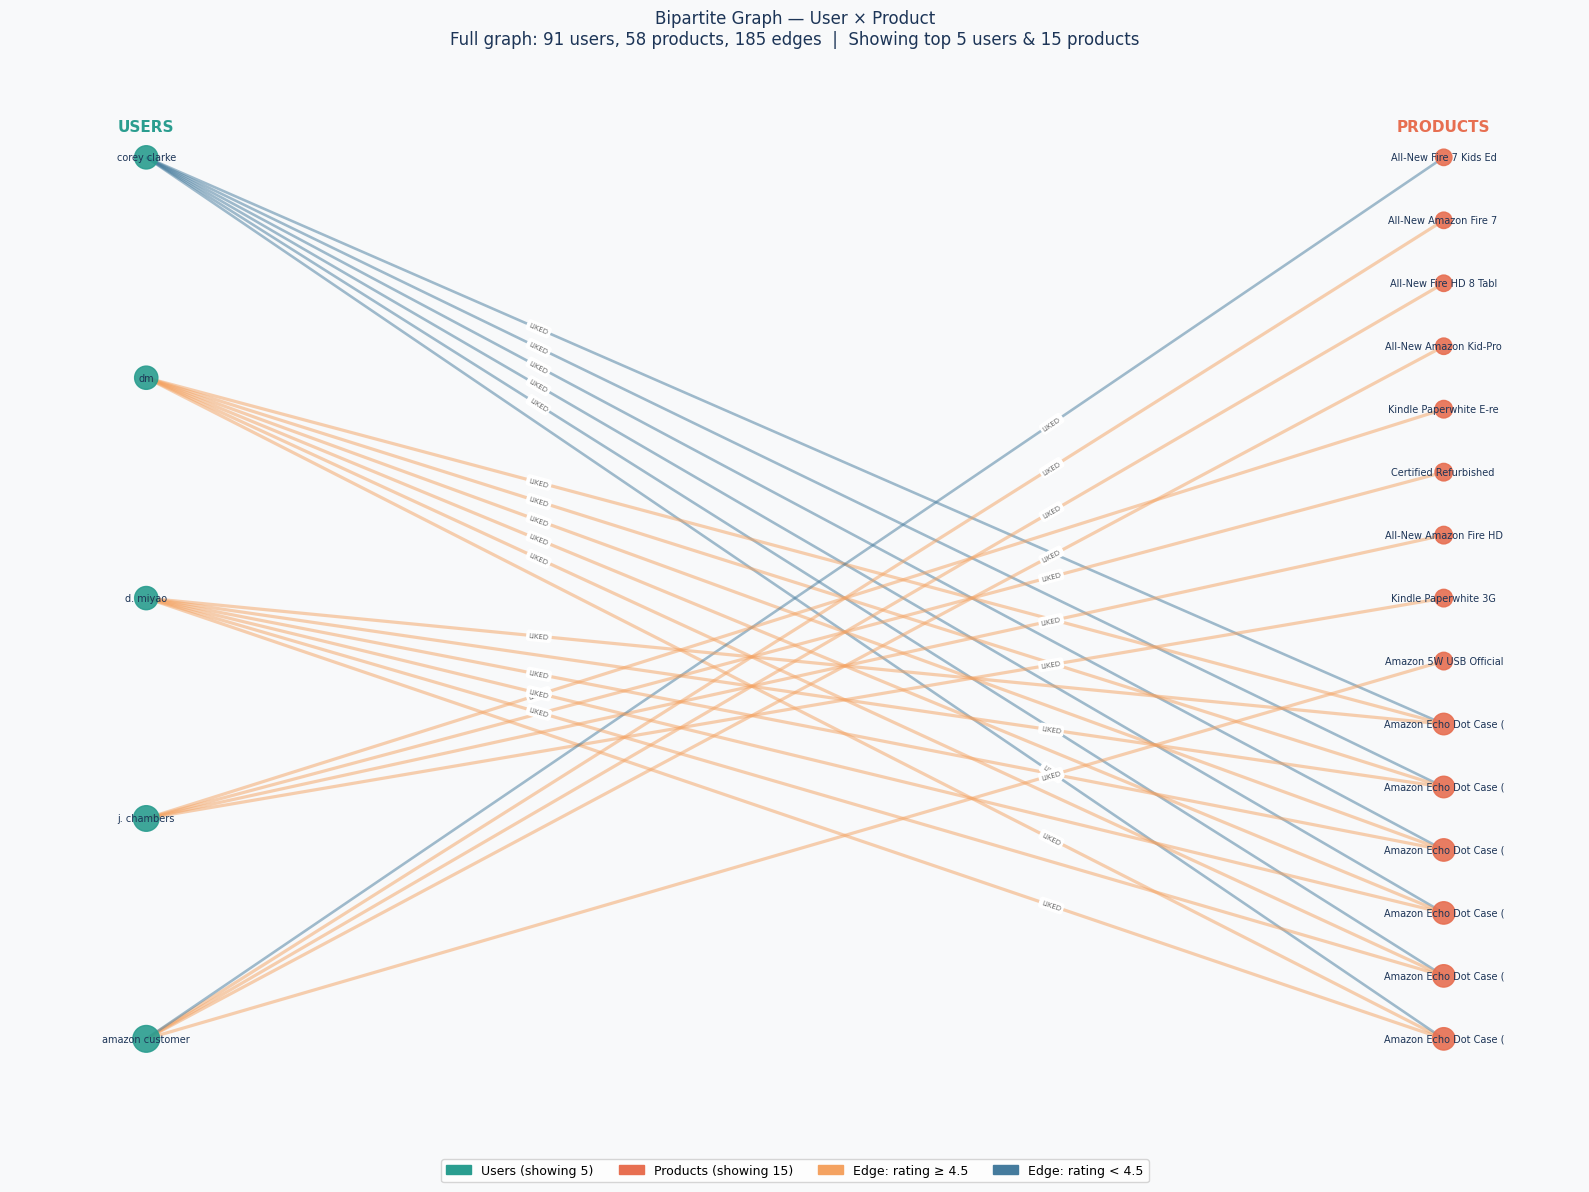

[viz] Saved → bipartite_graph.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from networkx.algorithms import bipartite

# ── Visualization ──────────────────────────────────────────────────────────────
def visualize_bipartite_graph(B: nx.Graph, max_users: int = 2, max_products: int = 2):
    """
    Visualize a sample of the bipartite graph.
    Sampling is needed since full graph will be unreadable.
    """
    # ── Sample nodes for readability ──
    user_nodes    = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 0]
    product_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 1]

    # Pick users with the most edges (most active reviewers)
    user_degrees   = sorted(user_nodes, key=lambda u: B.degree(u), reverse=True)
    sampled_users  = user_degrees[:max_users]

    # Pick products connected to sampled users only
    connected_products = set()
    for u in sampled_users:
        connected_products.update(B.neighbors(u))
    sampled_products = sorted(connected_products, key=lambda p: B.degree(p), reverse=True)[:max_products]

    # Induced subgraph
    sampled_nodes = set(sampled_users) | set(sampled_products)
    SG = B.subgraph(sampled_nodes)

    # ── Layout: two columns ──
    pos = {}
    # Users on left (x=0), products on right (x=1)
    for i, u in enumerate(sampled_users):
        pos[u] = (0, i / max(len(sampled_users) - 1, 1))
    for i, p in enumerate(sampled_products):
        pos[p] = (1, i / max(len(sampled_products) - 1, 1))

    # ── Edge weights → line widths & colors ──
    edges      = list(SG.edges(data=True))
    weights    = [d.get("weight", 1) for _, _, d in edges]
    edge_widths = [0.3 + (w / 5.0) * 2.0 for w in weights]   # scale 1-5 → 0.5-2.5
    edge_colors = ["#f4a261" if w >= 4.5 else "#457b9d" for w in weights]

    # ── Node sizes: degree-proportional ──
    user_sizes    = [100 + B.degree(n) * 30  for n in sampled_users]
    product_sizes = [100 + B.degree(n) * 20  for n in sampled_products]

    fig, ax = plt.subplots(figsize=(16, 12))
    ax.set_facecolor("#f8f9fa")
    fig.patch.set_facecolor("#f8f9fa")

    # Draw edges
    nx.draw_networkx_edges(
        SG, pos,
        edgelist   = [(u, v) for u, v, _ in edges],
        width      = edge_widths,
        edge_color = edge_colors,
        alpha      = 0.5,
        ax         = ax,
    )
    edge_label_dict = {(u, v): "LIKED" for u, v, _ in edges}
    nx.draw_networkx_edge_labels(
    SG, pos,
    edge_labels = edge_label_dict,
    font_size   = 5,
    font_color  = "#6b6b6b",
    label_pos   = 0.3,      # 0=near source, 0.5=center, 1=near target
    ax          = ax,
    )

    # Draw user nodes
    nx.draw_networkx_nodes(
        SG, pos,
        nodelist   = sampled_users,
        node_color = "#2a9d8f",
        node_size  = user_sizes,
        alpha      = 0.9,
        ax         = ax,
    )

    # Draw product nodes
    nx.draw_networkx_nodes(
        SG, pos,
        nodelist   = sampled_products,
        node_color = "#e76f51",
        node_size  = product_sizes,
        alpha      = 0.9,
        ax         = ax,
    )

    # Labels — truncate long product names
    user_labels    = {n: n[:15] for n in sampled_users}
    product_labels = {n: n[:22] for n in sampled_products}
    all_labels     = {**user_labels, **product_labels}

    nx.draw_networkx_labels(
        SG, pos,
        labels    = all_labels,
        font_size = 7,
        font_color = "#1d3557",
        ax        = ax,
    )

    # ── Legend & annotations ──
    legend_elements = [
        mpatches.Patch(color="#2a9d8f", label=f"Users (showing {len(sampled_users)})"),
        mpatches.Patch(color="#e76f51", label=f"Products (showing {len(sampled_products)})"),
        mpatches.Patch(color="#f4a261", label="Edge: rating ≥ 4.5"),
        mpatches.Patch(color="#457b9d", label="Edge: rating < 4.5"),
    ]
    ax.legend(handles=legend_elements, loc="upper center",
              bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=9)

    ax.set_title(
        f"Bipartite Graph — User × Product\n"
        f"Full graph: {len(user_nodes)} users, {len(product_nodes)} products, "
        f"{B.number_of_edges()} edges  |  "
        f"Showing top {len(sampled_users)} users & {len(sampled_products)} products",
        fontsize=12, pad=15, color="#1d3557"
    )

    # Column headers
    ax.text(0, 1.03, "USERS",    transform=ax.transData, ha="center",
            fontsize=11, fontweight="bold", color="#2a9d8f")
    ax.text(1, 1.03, "PRODUCTS", transform=ax.transData, ha="center",
            fontsize=11, fontweight="bold", color="#e76f51")

    ax.axis("off")
    plt.tight_layout()
    plt.savefig("bipartite_graph.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[viz] Saved → bipartite_graph.png")


print("\n=== Step 3: Visualize Bipartite Graph ===")
visualize_bipartite_graph(B, max_users=5, max_products=15)

In [18]:
from itertools import combinations
from collections import defaultdict
import community as community_louvain  # pip install python-louvain

# ── 3. Project Bipartite → User-User Graph ─────────────────────────────────────
def project_user_graph(B: nx.Graph) -> nx.Graph:
    """
    User-user graph where edge weight = Jaccard similarity
    of their liked product sets.
    """
    user_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == 0]
    
    UU = nx.Graph()
    UU.add_nodes_from(user_nodes)

    # Build neighbor sets once — O(U) not O(U²) repeated lookups
    neighbor_sets = {u: set(B.neighbors(u)) for u in user_nodes}

    for u1, u2 in combinations(user_nodes, 2):
        s1, s2 = neighbor_sets[u1], neighbor_sets[u2]
        intersection = len(s1 & s2)
        if intersection == 0:
            continue                          # no shared products → skip edge
        union = len(s1 | s2)
        jaccard = intersection / union
        if jaccard > 0.0:                     # only add meaningful edges
            UU.add_edge(u1, u2, weight=jaccard)

    print(f"[project] User-user graph: {UU.number_of_nodes()} nodes, "
          f"{UU.number_of_edges()} edges")
    return UU, neighbor_sets


In [19]:
def detect_communities(UU: nx.Graph) -> dict:
    """
    Louvain community detection on user-user graph.
    Returns: {user: community_id}
    """
    partition = community_louvain.best_partition(UU, weight="weight", random_state=42)
    
    # Summary
    from collections import Counter
    community_sizes = Counter(partition.values())
    print(f"[community] {len(community_sizes)} communities detected")
    for cid, size in sorted(community_sizes.items(), key=lambda x: -x[1])[:5]:
        print(f"  Community {cid}: {size} users")
    
    return partition


In [20]:
# ── 5. Naive Jaccard Recommendation ───────────────────────────────────────────
def recommend(
    target_user:   str,
    B:             nx.Graph,
    UU:            nx.Graph,
    neighbor_sets: dict,
    partition:     dict,
    top_k_users:   int = 10,
    top_n_recs:    int = 5,
) -> list[dict]:
    """
    For target_user:
      1. Find top-K similar users by Jaccard (UU edge weights)
      2. Collect their liked products
      3. Filter already-liked products
      4. Score = sum(jaccard_score) for each candidate product
      5. Return top-N ranked products
    """
    if target_user not in UU:
        print(f"[recommend] '{target_user}' not in user-user graph.")
        return []

    # Step 1 — top-K similar users
    neighbors = sorted(
        UU[target_user].items(),
        key=lambda x: x[1]["weight"],
        reverse=True
    )[:top_k_users]

    if not neighbors:
        print(f"[recommend] No similar users found for '{target_user}'.")
        return []

    # Step 2 & 3 — candidate products not yet liked by target user
    already_liked = neighbor_sets.get(target_user, set())
    
    product_scores = defaultdict(float)   # product → cumulative jaccard score
    product_freq   = defaultdict(int)     # product → how many similar users liked it

    for similar_user, edge_data in neighbors:
        jaccard = edge_data["weight"]
        for product in neighbor_sets[similar_user]:
            if product not in already_liked:
                product_scores[product] += jaccard
                product_freq[product]   += 1

    if not product_scores:
        print(f"[recommend] No new products to recommend for '{target_user}'.")
        return []

    # Step 4 — rank by combined score (jaccard_sum * frequency)
    ranked = sorted(
        product_scores.items(),
        key=lambda x: (product_freq[x[0]], x[1]),   # freq first, then jaccard
        reverse=True
    )[:top_n_recs]

    # Step 5 — attach product metadata
    results = []
    for product, score in ranked:
        meta = B.nodes.get(product, {})
        results.append({
            "product":     product,
            "brand":       meta.get("brand", "?"),
            "category":    meta.get("category", "?"),
            "avg_rating":  meta.get("avg_rating", "?"),
            "jaccard_score": round(score, 4),
            "freq":        product_freq[product],
            "community":   partition.get(target_user, "?"),
        })

    return results


In [23]:
# ── 6. Pretty Print Results ───────────────────────────────────────────────────
def print_recommendations(target_user: str, recs: list[dict]):
    print(f"\n{'='*60}")
    print(f"Recommendations for: {target_user}")
    print(f"{'='*60}")
    if not recs:
        print("  No recommendations found.")
        return
    for i, r in enumerate(recs, 1):
        print(f"\n  {i}. {r['product']}")
        print(f"     Brand     : {r['brand']}")
        print(f"     Category  : {r['category']}")
        print(f"     Avg Rating: {r['avg_rating']}")
        print(f"     Jaccard   : {r['jaccard_score']}  |  Liked by {r['freq']} similar users")
        print(f"     Community : {r['community']}")


# ── Run ───────────────────────────────────────────────────────────────────────
print("\n=== Step 3: Project User-User Graph ===")
UU, neighbor_sets = project_user_graph(B)

print("\n=== Step 4: Community Detection ===")
partition = detect_communities(UU)

# print("\n=== Step 5: Recommendations ===")
# # Pick any user from your dataset to test
# target = df["username"].value_counts().index[0]   # most active user
# recs   = recommend(target, B, UU, neighbor_sets, partition, top_k_users=10, top_n_recs=5)
# print_recommendations(target, recs)


=== Step 3: Project User-User Graph ===
[project] User-user graph: 91 nodes, 275 edges

=== Step 4: Community Detection ===
[community] 26 communities detected
  Community 15: 20 users
  Community 22: 13 users
  Community 3: 8 users
  Community 2: 6 users
  Community 25: 6 users
